In [7]:
# Cellule 1 — Imports & configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings("ignore")

# 1. Utiliser le chemin absolu pour plus de fiabilité dans Jupyter
notebook_dir = os.getcwd()
env_path = os.path.abspath(os.path.join(notebook_dir, ".env"))
load_dotenv(env_path)

# 2. Récupérer et transformer l'URL
raw_url = os.getenv("DATABASE_URL")

if raw_url is None:
    raise ValueError(f"❌ Impossible de trouver DATABASE_URL. Fichier .env cherché ici : {env_path}")

# On s'assure d'utiliser le driver psycopg comme dans database.py
database_url = raw_url.replace("postgresql://", "postgresql+psycopg://")

# 3. Création de l'engine
engine = create_engine(database_url)

# Style des graphiques
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

# Test rapide de connexion
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
    print(f"✅ Connexion établie avec succès à : {raw_url.split('@')[-1]}")

✅ Connexion établie avec succès à : localhost:5435/bloodflow_db


In [8]:
# Cellule 2 — Chargement de toutes les tables

df_stocks = pd.read_sql("""
    SELECT s.*, h.name as hospital_name, h.region, h.capacity_level
    FROM stocks s
    JOIN hospitals h ON s.hospital_id = h.id
    ORDER BY s.date, s.hospital_id
""", engine, parse_dates=["date"])

df_transfusions = pd.read_sql("""
    SELECT t.*, h.name as hospital_name, h.region, h.capacity_level
    FROM transfusions t
    JOIN hospitals h ON t.hospital_id = h.id
    ORDER BY t.date, t.hospital_id
""", engine, parse_dates=["date"])

df_dons = pd.read_sql("""
    SELECT d.*, h.name as hospital_name, h.region, h.capacity_level
    FROM dons d
    JOIN hospitals h ON d.hospital_id = h.id
    ORDER BY d.date, d.hospital_id
""", engine, parse_dates=["date"])

df_events = pd.read_sql("SELECT * FROM events", engine, parse_dates=["start_date", "end_date"])

print(f"Stocks       : {len(df_stocks):,} lignes")
print(f"Transfusions : {len(df_transfusions):,} lignes")
print(f"Dons         : {len(df_dons):,} lignes")
print(f"Événements   : {len(df_events):,} lignes")

Stocks       : 187,136 lignes
Transfusions : 34,059 lignes
Dons         : 22,130 lignes
Événements   : 14 lignes


In [9]:
# Cellule 3 — Statistiques descriptives des stocks

print("=== APERÇU DES DONNÉES DE STOCK ===\n")
print(df_stocks[["blood_type", "product_type", "quantity", 
                  "minimum_threshold", "expiring_soon"]].describe().round(1))

=== APERÇU DES DONNÉES DE STOCK ===

       quantity  minimum_threshold  expiring_soon
count  187136.0           187136.0       187136.0
mean       89.6               11.8            4.3
std       233.7               12.4           12.3
min         0.0                1.0            0.0
25%         1.0                4.5            0.0
50%         1.0                7.5            0.0
75%        29.0               12.5            1.0
max      2528.0               50.0          188.0


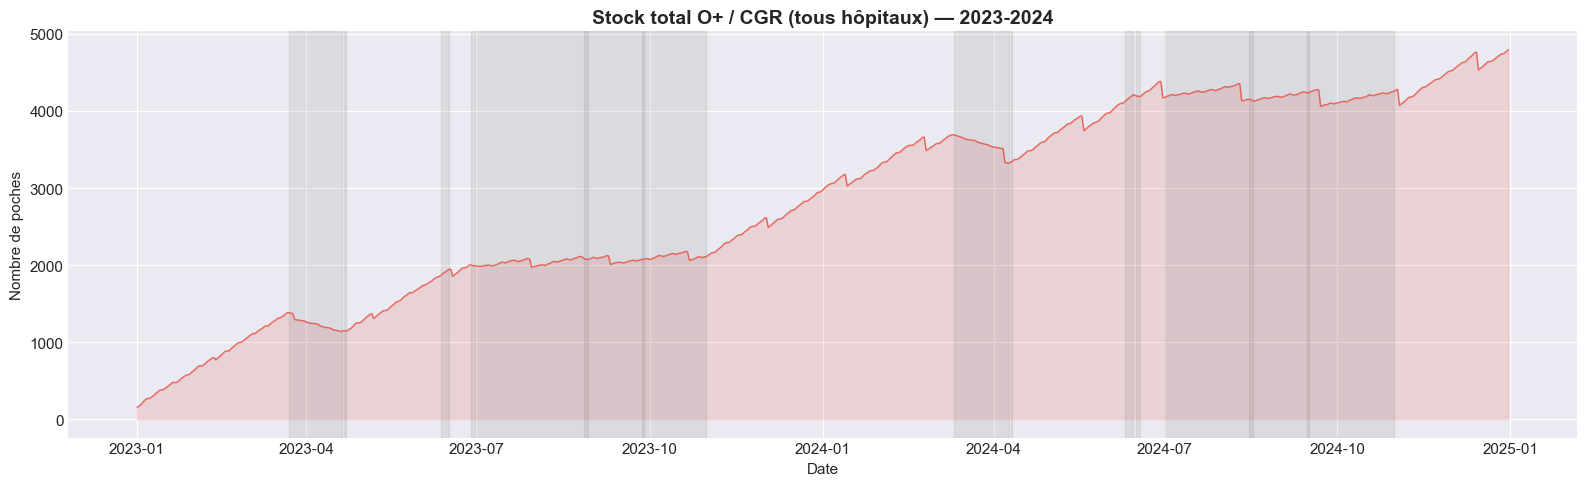

💡 Observez les creux pendant le Magal et la saison des pluies !


In [11]:
# Cellule 4 — Évolution temporelle des stocks CGR pour O_POS
# On commence par le groupe le plus courant pour valider nos patterns

df_cgr_opos = df_stocks[
    (df_stocks["product_type"] == "CGR") & 
    (df_stocks["blood_type"] == "O_POS")
].copy()

# Stock quotidien total (tous hôpitaux confondus)
daily_total = df_cgr_opos.groupby("date")["quantity"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total["date"], daily_total["quantity"], linewidth=1, color="#e74c3c", alpha=0.8)
ax.fill_between(daily_total["date"], daily_total["quantity"], alpha=0.15, color="#e74c3c")

# Ajout des événements sur le graphe
colors_event = {"religieux": "purple", "saisonnier": "blue", 
                "campagne_don": "green", "accident_masse": "red"}

for _, event in df_events.iterrows():
    color = colors_event.get(event["event_type"], "gray")
    ax.axvspan(event["start_date"], event["end_date"], 
               alpha=0.15, color=color, label=event["name"])

ax.set_title("Stock total O+ / CGR (tous hôpitaux) — 2023-2024", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre de poches")
plt.tight_layout()
plt.savefig("data/processed/stock_cgr_opos_evolution.png", dpi=150)
plt.show()

print("💡 Observez les creux pendant le Magal et la saison des pluies !")

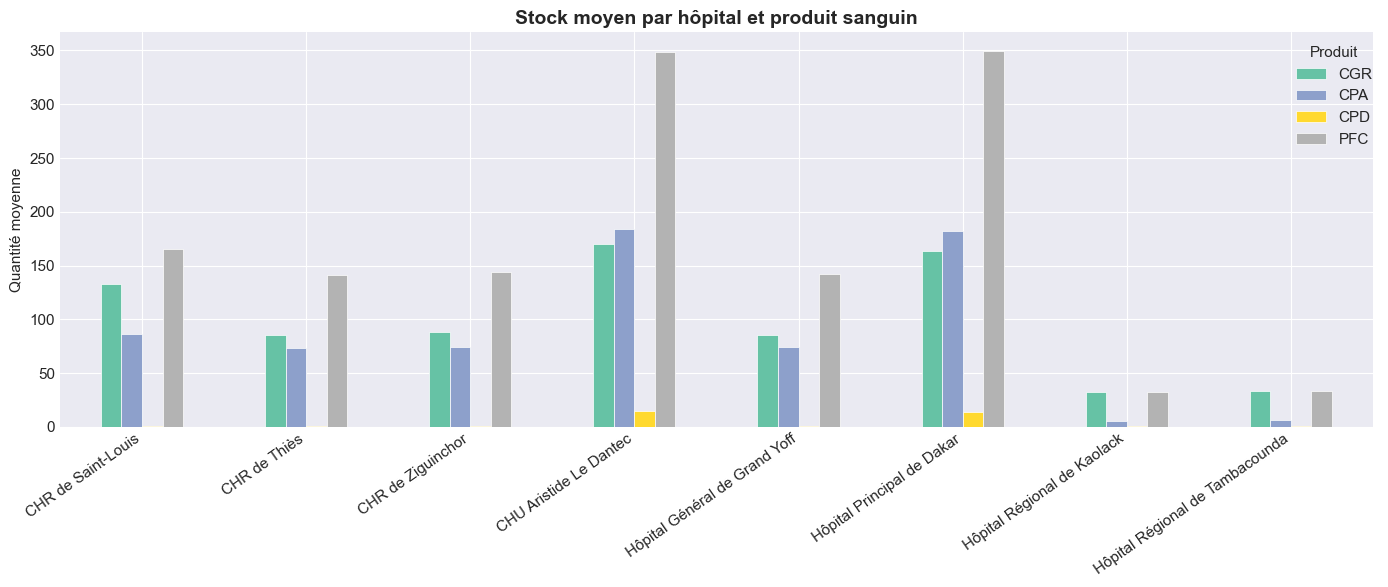

In [14]:
# Cellule 5 — Comparaison des stocks moyens par hôpital et produit

pivot = df_stocks.groupby(["hospital_name", "product_type"])["quantity"].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", linewidth=0.5)

ax.set_title("Stock moyen par hôpital et produit sanguin", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Quantité moyenne")
ax.legend(title="Produit", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("data/processed/stock_par_hopital_produit.png", dpi=150)
plt.show()

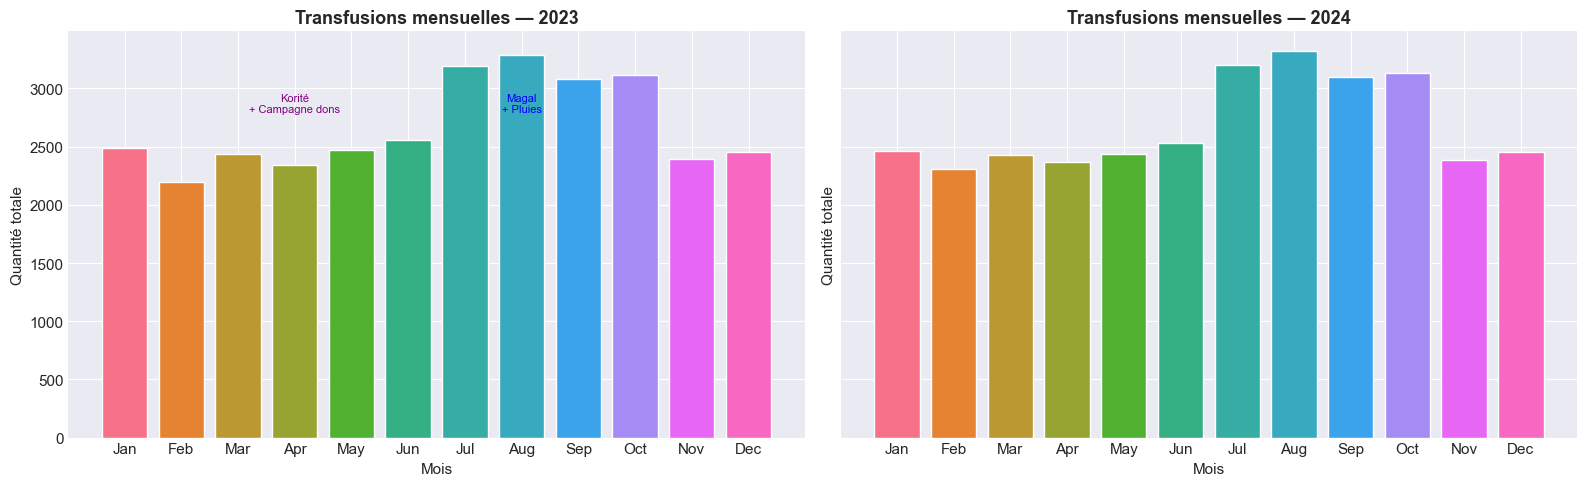

💡 Les pics d'août (Magal + saison des pluies) sont bien visibles !


In [15]:
# Cellule 6 — Saisonnalité mensuelle des transfusions
# On veut vérifier que nos événements ont bien créé des pics réalistes

df_transfusions["month"] = df_transfusions["date"].dt.month
df_transfusions["month_name"] = df_transfusions["date"].dt.strftime("%b")
df_transfusions["year"] = df_transfusions["date"].dt.year

monthly = df_transfusions.groupby(["year", "month", "month_name"])["quantity"].sum().reset_index()
monthly = monthly.sort_values(["year", "month"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for idx, year in enumerate([2023, 2024]):
    data = monthly[monthly["year"] == year]
    axes[idx].bar(data["month_name"], data["quantity"], 
                  color=sns.color_palette("husl", 12), edgecolor="white")
    axes[idx].set_title(f"Transfusions mensuelles — {year}", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("Mois")
    axes[idx].set_ylabel("Quantité totale")

    # Annotations des événements clés
    if year == 2023:
        axes[idx].annotate("Korité\n+ Campagne dons", xy=(3, data[data["month"]==4]["quantity"].values[0]),
                          xytext=(3, data["quantity"].max() * 0.85),
                          fontsize=8, color="purple", ha="center")
        axes[idx].annotate("Magal\n+ Pluies", xy=(7, data[data["month"]==8]["quantity"].values[0]),
                          xytext=(7, data["quantity"].max() * 0.85),
                          fontsize=8, color="blue", ha="center")

plt.tight_layout()
plt.savefig("data/processed/transfusions_saisonnalite.png", dpi=150)
plt.show()

print("💡 Les pics d'août (Magal + saison des pluies) sont bien visibles !")

=== TOP 10 DES SITUATIONS DE PÉNURIE ===

                  hospital_name product_type  jours_penurie  taux_penurie_%
              CHR de Ziguinchor          CPD           5848           100.0
             CHR de Saint-Louis          CPD           5848           100.0
                   CHR de Thiès          CPD           5848           100.0
  Hôpital Général de Grand Yoff          CPD           5848           100.0
         CHU Aristide Le Dantec          CPD           5120            87.6
Hôpital Régional de Tambacounda          CPA           5120            87.6
     Hôpital Principal de Dakar          CPD           5120            87.6
    Hôpital Régional de Kaolack          CPA           5119            87.5
Hôpital Régional de Tambacounda          PFC           4400            75.2
    Hôpital Régional de Kaolack          PFC           4395            75.2


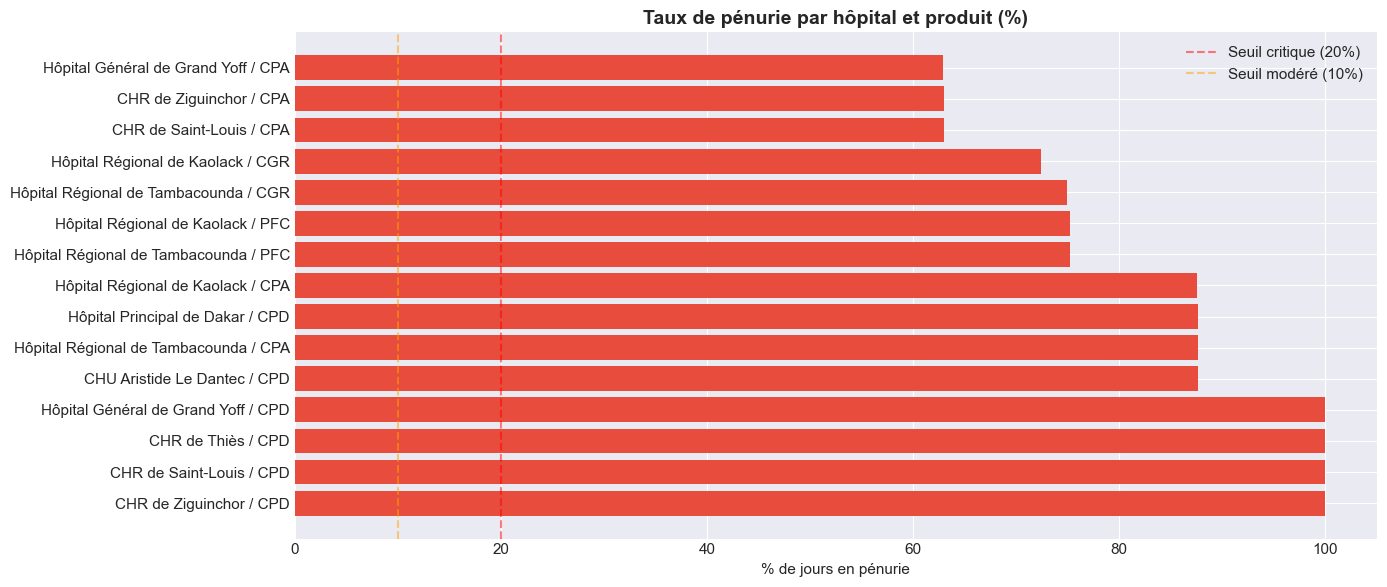

In [16]:
# Cellule 7 — Identifier les jours où le stock passe sous le seuil minimum
# C'est exactement ce que notre modèle devra PRÉDIRE en avance

df_stocks["is_shortage"] = df_stocks["quantity"] < df_stocks["minimum_threshold"]
df_stocks["shortage_ratio"] = (df_stocks["quantity"] / df_stocks["minimum_threshold"]).round(2)

shortage_summary = df_stocks.groupby(["hospital_name", "product_type"]).agg(
    jours_total=("date", "count"),
    jours_penurie=("is_shortage", "sum"),
    stock_moyen=("quantity", "mean"),
    seuil_moyen=("minimum_threshold", "mean")
).reset_index()

shortage_summary["taux_penurie_%"] = (
    shortage_summary["jours_penurie"] / shortage_summary["jours_total"] * 100
).round(1)

shortage_summary = shortage_summary.sort_values("taux_penurie_%", ascending=False)

print("=== TOP 10 DES SITUATIONS DE PÉNURIE ===\n")
print(shortage_summary[["hospital_name", "product_type", 
                          "jours_penurie", "taux_penurie_%"]].head(10).to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
top = shortage_summary.head(15)
bars = ax.barh(
    top["hospital_name"] + " / " + top["product_type"],
    top["taux_penurie_%"],
    color=["#e74c3c" if x > 20 else "#f39c12" if x > 10 else "#2ecc71" 
           for x in top["taux_penurie_%"]]
)
ax.set_title("Taux de pénurie par hôpital et produit (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("% de jours en pénurie")
ax.axvline(x=20, color="red", linestyle="--", alpha=0.5, label="Seuil critique (20%)")
ax.axvline(x=10, color="orange", linestyle="--", alpha=0.5, label="Seuil modéré (10%)")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/taux_penurie.png", dpi=150)
plt.show()

In [17]:
# Cellule 8 — Feature Engineering
# C'est la cellule la plus importante : on transforme les données brutes
# en features exploitables par notre modèle de prédiction

print("Construction des features ML...")

# ── Base : stocks quotidiens ──────────────────────────
df_feat = df_stocks.copy().sort_values(["hospital_id", "blood_type", "product_type", "date"])

# ── Features temporelles ──────────────────────────────
df_feat["day_of_week"]  = df_feat["date"].dt.dayofweek   # 0=lundi, 6=dimanche
df_feat["month"]        = df_feat["date"].dt.month
df_feat["is_weekend"]   = (df_feat["day_of_week"] >= 5).astype(int)
df_feat["is_rainy_season"] = df_feat["month"].isin([7, 8, 9, 10]).astype(int)
df_feat["is_ramadan_2023"] = df_feat["date"].between("2023-03-23", "2023-04-20").astype(int)
df_feat["is_ramadan_2024"] = df_feat["date"].between("2024-03-11", "2024-04-09").astype(int)
df_feat["is_ramadan"]   = df_feat[["is_ramadan_2023", "is_ramadan_2024"]].max(axis=1)
df_feat = df_feat.drop(columns=["is_ramadan_2023", "is_ramadan_2024"])

# ── Lag features (stock des jours précédents) ─────────
group_keys = ["hospital_id", "blood_type", "product_type"]

for lag in [1, 2, 3, 7, 14]:
    df_feat[f"stock_lag_{lag}"] = df_feat.groupby(group_keys)["quantity"].shift(lag)

# ── Rolling features (moyennes mobiles) ───────────────
df_feat["stock_rolling_7d"]  = df_feat.groupby(group_keys)["quantity"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
df_feat["stock_rolling_30d"] = df_feat.groupby(group_keys)["quantity"].transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).mean()
)

# ── Consommation (transfusions) agrégée ───────────────
daily_transf = df_transfusions.groupby(
    ["hospital_id", "blood_type", "product_type", "date"]
)["quantity"].sum().reset_index()
daily_transf.columns = ["hospital_id", "blood_type", "product_type", "date", "daily_transf"]

df_feat = df_feat.merge(daily_transf, on=["hospital_id", "blood_type", "product_type", "date"], how="left")
df_feat["daily_transf"] = df_feat["daily_transf"].fillna(0)

df_feat["transf_rolling_7d"]  = df_feat.groupby(group_keys)["daily_transf"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)
df_feat["transf_rolling_30d"] = df_feat.groupby(group_keys)["daily_transf"].transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).mean()
)

# ── Dons agrégés ──────────────────────────────────────
daily_dons = df_dons.groupby(["hospital_id", "blood_type", "date"])["quantity"].sum().reset_index()
daily_dons.columns = ["hospital_id", "blood_type", "date", "daily_dons"]

df_feat = df_feat.merge(daily_dons, on=["hospital_id", "blood_type", "date"], how="left")
df_feat["daily_dons"] = df_feat["daily_dons"].fillna(0)
df_feat["dons_rolling_7d"] = df_feat.groupby(group_keys)["daily_dons"].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

# ── Features événementielles ──────────────────────────
# Pour chaque jour, on calcule le nombre de jours avant le prochain événement
all_event_dates = []
for _, e in df_events.iterrows():
    d = e["start_date"]
    while d <= e["end_date"]:
        all_event_dates.append(d)
        d += pd.Timedelta(days=1)
all_event_dates = sorted(set(all_event_dates))

def days_to_next_event(current_date):
    future = [d for d in all_event_dates if d >= current_date]
    return (future[0] - current_date).days if future else 999

date_to_days_next = {d: days_to_next_event(d) for d in df_feat["date"].unique()}
df_feat["days_to_next_event"] = df_feat["date"].map(date_to_days_next)
df_feat["is_during_event"]    = df_feat["date"].isin(all_event_dates).astype(int)

# ── Encodages catégoriels ──────────────────────────────
from sklearn.preprocessing import LabelEncoder

le_bt   = LabelEncoder()
le_prod = LabelEncoder()
le_cap  = LabelEncoder()

df_feat["blood_type_enc"]    = le_bt.fit_transform(df_feat["blood_type"])
df_feat["product_type_enc"]  = le_prod.fit_transform(df_feat["product_type"])
df_feat["capacity_enc"]      = le_cap.fit_transform(df_feat["capacity_level"])

# ── Rareté du groupe sanguin ───────────────────────────
rarity_map = {
    "O_POS":1, "A_POS":2, "B_POS":3, "AB_POS":4,
    "O_NEG":5, "A_NEG":6, "B_NEG":7, "AB_NEG":8
}
df_feat["blood_type_rarity"] = df_feat["blood_type"].map(rarity_map)

# ── Variable cible ─────────────────────────────────────
# On prédit si dans J+3 il y aura pénurie (stock < seuil)
df_feat["target_shortage_j3"] = (
    df_feat.groupby(group_keys)["is_shortage"].shift(-3)
).astype("Int64")  # Int64 supporte les NaN

# ── Nettoyage final ────────────────────────────────────
df_feat = df_feat.dropna(subset=["stock_lag_7", "target_shortage_j3"])

print(f"✅ Dataset ML prêt : {len(df_feat):,} lignes, {len(df_feat.columns)} colonnes")
print(f"\nDistribution de la cible (pénurie dans J+3) :")
print(df_feat["target_shortage_j3"].value_counts(normalize=True).round(3) * 100)

Construction des features ML...
✅ Dataset ML prêt : 184,576 lignes, 37 colonnes

Distribution de la cible (pénurie dans J+3) :
target_shortage_j3
1    69.1
0    30.9
Name: proportion, dtype: Float64


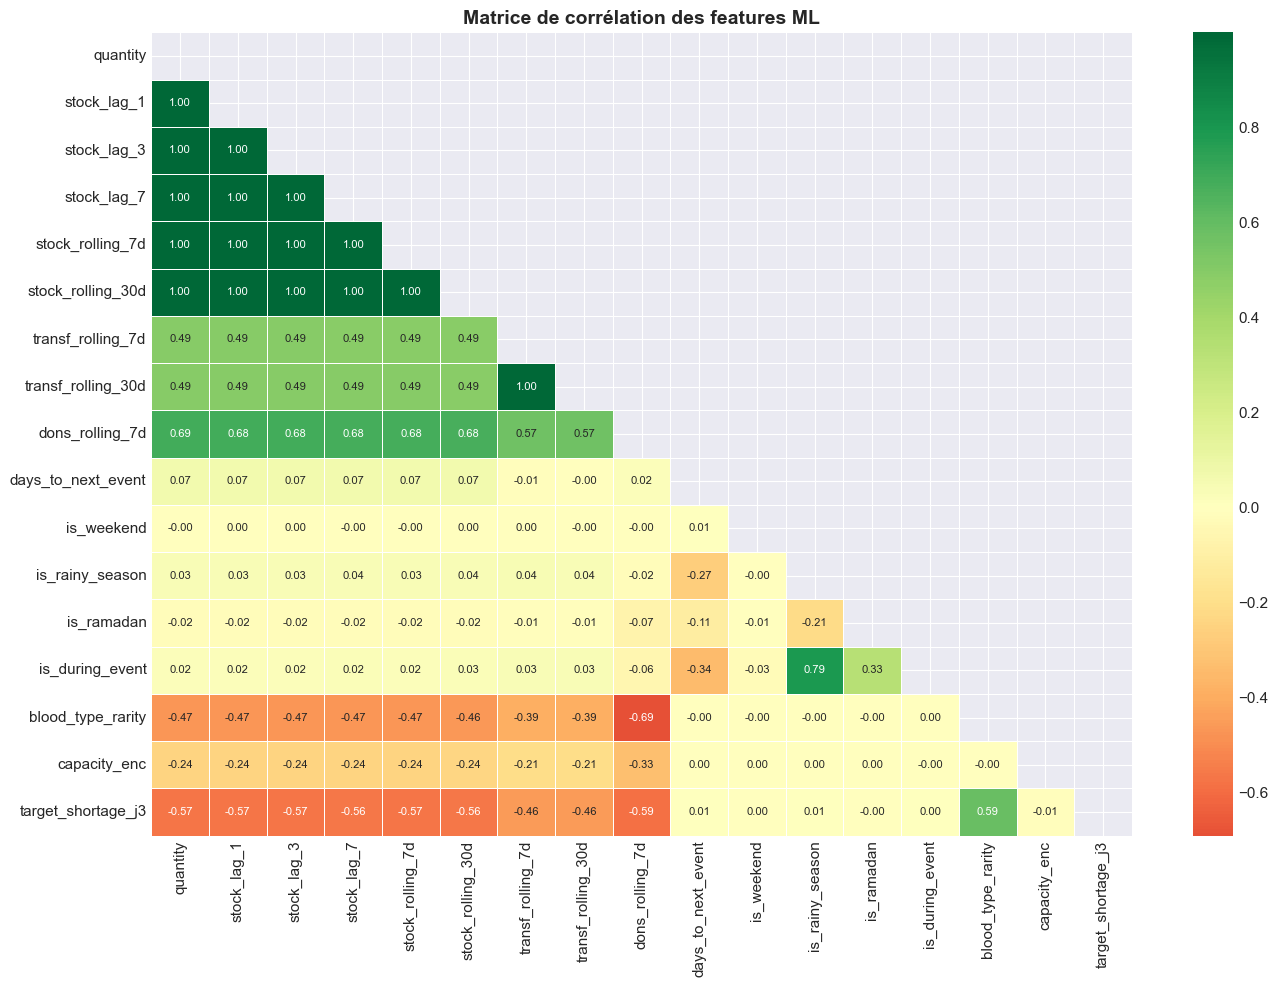


💡 Les features les plus corrélées à la cible (target_shortage_j3) :
blood_type_rarity    0.588
dons_rolling_7d      0.585
quantity             0.567
stock_lag_1          0.567
stock_lag_3          0.566
stock_rolling_7d     0.566
stock_lag_7          0.564
stock_rolling_30d    0.561
Name: target_shortage_j3, dtype: float64


In [19]:
# Cellule 9 — Corrélations entre features et la cible
# Permet de voir quelles features sont les plus prédictives

feature_cols = [
    "quantity", "stock_lag_1", "stock_lag_3", "stock_lag_7",
    "stock_rolling_7d", "stock_rolling_30d",
    "transf_rolling_7d", "transf_rolling_30d",
    "dons_rolling_7d", "days_to_next_event",
    "is_weekend", "is_rainy_season", "is_ramadan",
    "is_during_event", "blood_type_rarity", "capacity_enc",
    "target_shortage_j3"
]

corr_matrix = df_feat[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    annot_kws={"size": 8}, linewidths=0.5
)
ax.set_title("Matrice de corrélation des features ML", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/correlation_matrix.png", dpi=150)
plt.show()

print("\n💡 Les features les plus corrélées à la cible (target_shortage_j3) :")
corr_target = corr_matrix["target_shortage_j3"].drop("target_shortage_j3").abs().sort_values(ascending=False)
print(corr_target.head(8).round(3))

In [20]:
# Cellule 10 — Sauvegarde du dataset prêt pour l'entraînement

import os
os.makedirs("data/processed", exist_ok=True)

# Colonnes finales pour le modèle
ml_columns = [
    "hospital_id", "blood_type", "product_type", "date",
    "quantity", "minimum_threshold", "expiring_soon",
    "stock_lag_1", "stock_lag_2", "stock_lag_3", "stock_lag_7", "stock_lag_14",
    "stock_rolling_7d", "stock_rolling_30d",
    "transf_rolling_7d", "transf_rolling_30d",
    "dons_rolling_7d",
    "day_of_week", "month", "is_weekend", "is_rainy_season", "is_ramadan",
    "days_to_next_event", "is_during_event",
    "blood_type_enc", "product_type_enc", "capacity_enc", "blood_type_rarity",
    "is_shortage", "target_shortage_j3"
]

df_ml = df_feat[ml_columns].copy()
df_ml.to_csv("data/processed/ml_dataset.csv", index=False)

print(f"✅ Dataset exporté : data/processed/ml_dataset.csv")
print(f"   Lignes   : {len(df_ml):,}")
print(f"   Colonnes : {len(df_ml.columns)}")
print(f"\nAperçu :")
print(df_ml.head(3).to_string())

✅ Dataset exporté : data/processed/ml_dataset.csv
   Lignes   : 184,576
   Colonnes : 30

Aperçu :
   hospital_id blood_type product_type       date  quantity  minimum_threshold  expiring_soon  stock_lag_1  stock_lag_2  stock_lag_3  stock_lag_7  stock_lag_14  stock_rolling_7d  stock_rolling_30d  transf_rolling_7d  transf_rolling_30d  dons_rolling_7d  day_of_week  month  is_weekend  is_rainy_season  is_ramadan  days_to_next_event  is_during_event  blood_type_enc  product_type_enc  capacity_enc  blood_type_rarity  is_shortage  target_shortage_j3
7            1     AB_NEG          CGR 2023-01-08         1                 50              0          2.0          1.0          0.0          0.0           NaN          0.428571           0.428571           0.142857            0.142857         0.285714            6      1           1                0           0                  74                0               0                 0             0                  8         True                   1

In [21]:
# Cellule 11 — Reconstruire une cible plus réaliste

# Nouvelle cible : stock dans J+3 sera < seuil * 1.5
# Cela anticipe le risque AVANT la pénurie réelle
df_feat["target_shortage_j3"] = (
    df_feat.groupby(group_keys)["quantity"].shift(-3) < 
    df_feat["minimum_threshold"] * 1.5
).astype("Int64")

# Vérifier la nouvelle distribution
print("Nouvelle distribution de la cible :")
print(df_feat["target_shortage_j3"].value_counts(normalize=True).round(3) * 100)

# Réexporter
ml_columns = [c for c in ml_columns if c != "is_shortage"]
df_ml = df_feat[ml_columns + ["target_shortage_j3"]].dropna(
    subset=["stock_lag_7", "target_shortage_j3"]
)
df_ml.to_csv("data/processed/ml_dataset.csv", index=False)
print(f"\n✅ Dataset corrigé exporté : {len(df_ml):,} lignes")

Nouvelle distribution de la cible :
target_shortage_j3
1    73.7
0    26.3
Name: proportion, dtype: Float64

✅ Dataset corrigé exporté : 184,576 lignes


In [22]:
# Cellule 11 (révisée) — Reconstruire une cible équilibrée

# Diagnostic : regardons la distribution réelle des stocks
print("=== DIAGNOSTIC DES STOCKS ===\n")

for prod in ["CGR", "PFC", "CPA", "CPD"]:
    subset = df_feat[df_feat["product_type"] == prod]["quantity"]
    print(f"{prod} → médiane: {subset.median():.0f} | "
          f"moyenne: {subset.mean():.0f} | "
          f"p10: {subset.quantile(0.10):.0f} | "
          f"p25: {subset.quantile(0.25):.0f}")

=== DIAGNOSTIC DES STOCKS ===

CGR → médiane: 2 | moyenne: 100 | p10: 1 | p25: 1
PFC → médiane: 1 | moyenne: 171 | p10: 1 | p25: 1
CPA → médiane: 1 | moyenne: 86 | p10: 1 | p25: 1
CPD → médiane: 1 | moyenne: 4 | p10: 0 | p25: 0


In [23]:
# Cellule 12 — Identifier où s'accumulent les stocks

print("=== STOCKS MOYENS PAR HÔPITAL ET PRODUIT ===\n")
pivot = df_feat.groupby(["hospital_name", "product_type"])["quantity"].median().unstack()
print(pivot.round(0).to_string())

print("\n\n=== ÉVOLUTION DU STOCK TOTAL CGR DANS LE TEMPS ===")
cgr_daily = df_feat[df_feat["product_type"] == "CGR"].groupby(["date", "hospital_name"])["quantity"].sum().unstack()
print("\nStock médian par hôpital (CGR) :")
print(cgr_daily.median().sort_values(ascending=False).round(0))

=== STOCKS MOYENS PAR HÔPITAL ET PRODUIT ===

product_type                      CGR  CPA  CPD  PFC
hospital_name                                       
CHR de Saint-Louis                6.0  1.0  1.0  1.0
CHR de Thiès                     10.0  1.0  1.0  1.0
CHR de Ziguinchor                 9.0  1.0  1.0  1.0
CHU Aristide Le Dantec            8.0  1.0  1.0  1.0
Hôpital Général de Grand Yoff     7.0  1.0  1.0  1.0
Hôpital Principal de Dakar        8.0  1.0  1.0  1.0
Hôpital Régional de Kaolack       1.0  1.0  1.0  1.0
Hôpital Régional de Tambacounda   1.0  1.0  1.0  1.0


=== ÉVOLUTION DU STOCK TOTAL CGR DANS LE TEMPS ===


Task was destroyed but it is pending!
task: <Task pending name='Task-197' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\bmd tech\Documents\bloodflow-senegal\venv\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-198' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\bmd tech\Documents\bloodflow-senegal\venv\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\bmd tech\Documents\bloodflow-senegal\venv\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-198' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\bmd tech\Documents\bloodflow-senegal\venv\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]>



Stock médian par hôpital (CGR) :
hospital_name
CHU Aristide Le Dantec             1423.0
Hôpital Principal de Dakar         1366.0
CHR de Saint-Louis                 1186.0
CHR de Ziguinchor                   750.0
Hôpital Général de Grand Yoff       710.0
CHR de Thiès                        705.0
Hôpital Régional de Tambacounda     282.0
Hôpital Régional de Kaolack         279.0
dtype: float64
